In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np


from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, matthews_corrcoef
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from Model import MultimodalClassificationDataset, PeptideClassifier

In [ ]:
# --- CSV Loading and Merging Function ---

def load_and_align_data(path_chemberta, path_esm, path_peptmtr, label_col='y'):
    """
    Reads 3 files, extracts embeddings and labels.
    Assumptions:
    1. All columns except label_col and 'ID' are embedding dimensions.
    2. The order of rows in all files is identical.
    """
    print(f"Loading data from:\n - {path_chemberta}\n - {path_esm}\n - {path_peptmtr}")
    df_chem = pd.read_csv(path_chemberta)
    df_esm = pd.read_csv(path_esm)
    df_mtr = pd.read_csv(path_peptmtr)

    # Check for length match

    assert len(df_chem) == len(df_esm) == len(df_mtr), "Error: Files have different numbers of rows!"

    # Extract labels (taking from the first file; checking match with the others is good practice)
    y = df_chem[label_col].values
    # Function to extract only numeric columns (embeddings)

    def get_feats(df):
        # Exclude labels and IDs, if they exist
        cols_to_drop = [c for c in df.columns if c in [label_col, 'Org_ind', 'ID', 'id', 'Sequence', 'Smiles', 'Canonical_smiles']]
        return df.drop(columns=cols_to_drop).values.astype(np.float32)

    embeddings = {
        'chemberta': get_feats(df_chem),
        'esm': get_feats(df_esm),
        'mtr': get_feats(df_mtr)

    }
    print(f"Loaded {len(y)} samples.")
    print(f"Dimensions: Chem={embeddings['chemberta'].shape}, ESM={embeddings['esm'].shape}, Mtr={embeddings['mtr'].shape}")
    return embeddings, y

In [ ]:
BATCH_SIZE = 32
path = 'Data'
folder = 'Half_life'
data_name = 'Half_life'

# Replace the paths with your actual files
test_embs, test_y = load_and_align_data(f'{path}/{folder}/{data_name}_test_chemberta.csv', f'{path}/{folder}/{data_name}_test_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_pmtr.csv')
#test_embs, test_y = load_and_align_data(f'{path}/{folder}/{data_name}_test_inside_chemberta.csv', f'{path}/{folder}/{data_name}_test_inside_esm2_t33_650M.csv', f'{path}/{folder}/{data_name}_test_inside_rdkit.csv')

# DataLoader creating
test_dataset = MultimodalClassificationDataset(test_embs, test_y)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# 2. Model initialization
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
emb_dims_1 = {
    'chemberta': 768,
    'esm': 1280
}

model = PeptideClassifier(emb_dims_1,  num_classes=3, hidden_dim=128).to(DEVICE)
model.load_state_dict(torch.load(f'Models/Half_life/Half_life_org_esm_chemb_68.pth'))

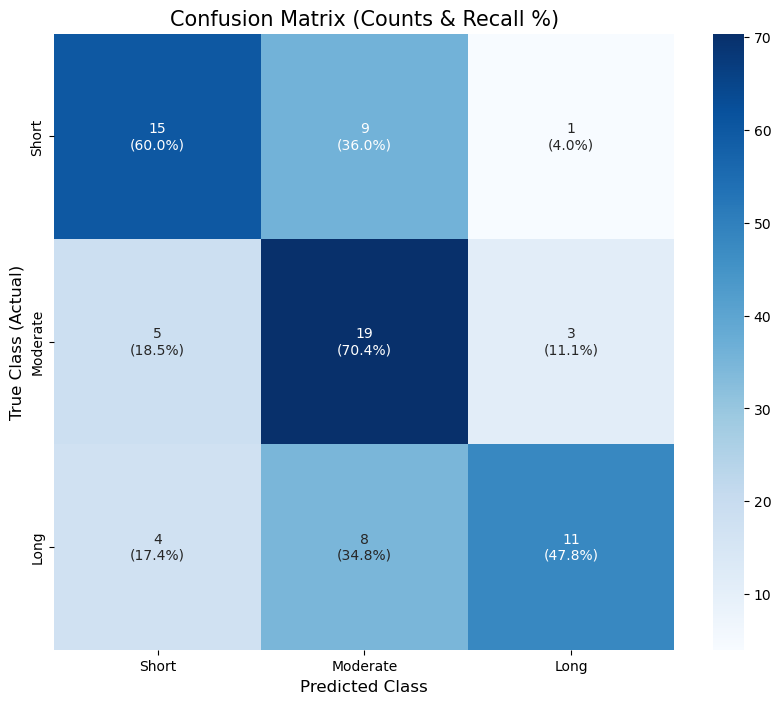

In [ ]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    for batch_embs, labels in loader:
        batch_embs = {k: v.to(device) for k, v in batch_embs.items()}
        output = model(batch_embs)
        if isinstance(output, tuple):
            logits = output[0]
        else:
            logits = output

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

    return all_targets, all_preds


y_true, y_pred = get_predictions(model, test_loader, DEVICE)
plot_pretty_confusion_matrix(y_true, y_pred)